In [1]:
import hoda
import tensorly as tl
tl.get_backend()

'cupy'

In [2]:
from moabb.paradigms import P300
from moabb.datasets import *

tmin = 0
tmax=0.8
fmin=0.5
fmax = 16
sfreq = 32

paradigm = P300(resample=sfreq, tmin=tmin, tmax=tmax, fmin=fmin, fmax=fmax)
dataset = BNCI2014_009()
epochs, labels, meta = paradigm.get_data(dataset=dataset, 
                                         subjects=[1],
                                         return_epochs=True)
session = meta['session'][0]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]

<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_types is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_channels_regexp is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.channel_type is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
/usr/local/lib/python3.10/dist-packages/moabb/pipelines/__init__.py:26: ModuleNotFoundError: Tensorflow is not installed. You won't be able to use these MOABB pipelines if you attempt to do so.
  warn(


To use the get_shape_from_baseconcar, InputShapeSetterEEG, BraindecodeDatasetLoaderyou need to install `braindecode`.`pip install braindecode` or Please refer to `https://braindecode.org`.
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
1728 matching events found
No baseline correction applied


/usr/local/lib/python3.10/dist-packages/moabb/paradigms/base.py:354: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  X = mne.concatenate_epochs(X)


In [3]:
meta

,subject,session,run
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0
...,...,...,...
571,1,0,0
572,1,0,0
573,1,0,0
574,1,0,0


In [4]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl

tl.set_backend('cupy')

X = epochs.get_data()
y = labels

X.shape

/tmp/ipykernel_4605/489331373.py:7: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  X = epochs.get_data()


(576, 16, 26)

In [5]:
from hoda.hoda import BTTDA, HODA
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import Scaler
import warnings
from sklearn.model_selection import GridSearchCV
from hoda.classification import Vectorize
from sklearn.feature_selection import SelectFwe
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

bttda = BTTDA(
    max_blocks=16,
    info_crit='bic',
    hoda_params=dict(
        rank=1,
        max_iter=256,
        tol=1e-8,
        init ='svd',
        shrinkage='lw',
        toeplitz=(1,),
        obj='rt',
        solver='lanczos',
        taper=False,
        keep_train_info=False,
        verbose=True,
    ),
    verbose=True,
    keep_train_info=True,
)
pipeline= Pipeline([
            ('bttda',bttda),
            ('vec', Vectorize()),
            ('select', SelectFwe()),
            ('zscore', StandardScaler()),
            ('lda', LinearDiscriminantAnalysis())
        ])

pipeline.fit(X,y)
bttda=pipeline['bttda']


Fitting block 1/8...
Initializing factors...
Fitting discriminative Tucker model...


  0%|          | 0/256 [00:00<?, ?it/s]

Fitted Tucker model of rank (1, 1) ...
Initializing factors...
Fitting discriminative Tucker model...


  0%|          | 0/256 [00:00<?, ?it/s]

Fitted Tucker model of rank (2, 2) ...
Initializing factors...
Fitting discriminative Tucker model...


...

Fitted Tucker model of rank (1, 1) ...
Initializing factors...
Fitting discriminative Tucker model...


  0%|          | 0/256 [00:00<?, ?it/s]

Fitted Tucker model of rank (2, 2) ...
Fitting block 5/8...
Initializing factors...
Fitting discriminative Tucker model...


  0%|          | 0/256 [00:00<?, ?it/s]

Fitted Tucker model of rank (1, 1) ...


In [6]:
bttda.train_info_

,mse,bic
block,,
1.0,2.036115e-11,168.112860
2.0,1.962576e-11,137.025844
3.0,1.950348e-11,129.137792
4.0,1.941166e-11,118.278080


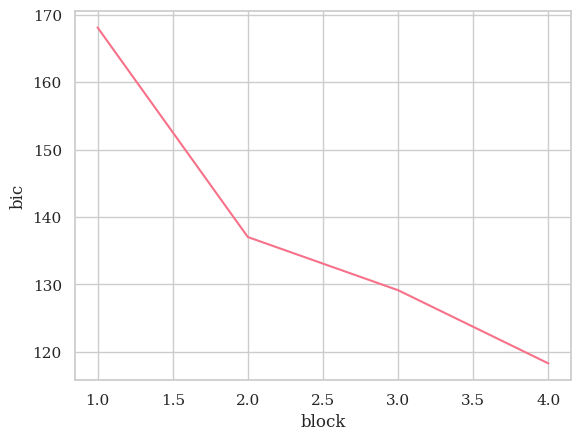

<Axes: xlabel='block', ylabel='mse'>

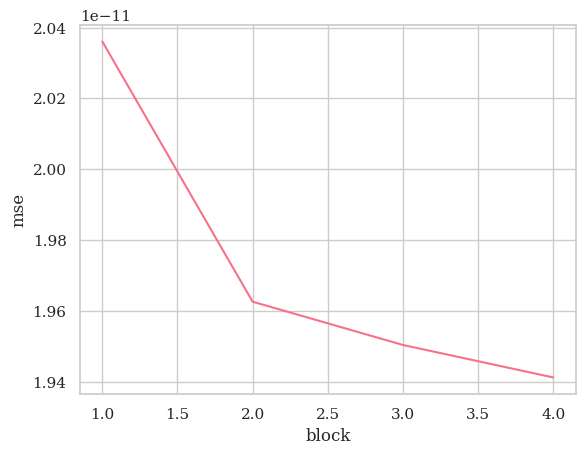

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(data=bttda.train_info_, x='block', y='bic')
plt.show()
sns.lineplot(data=bttda.train_info_, x='block', y='mse')

Not setting metadata
96 matching events found
No baseline correction applied
0 projection items activated
combining channels using "mean"


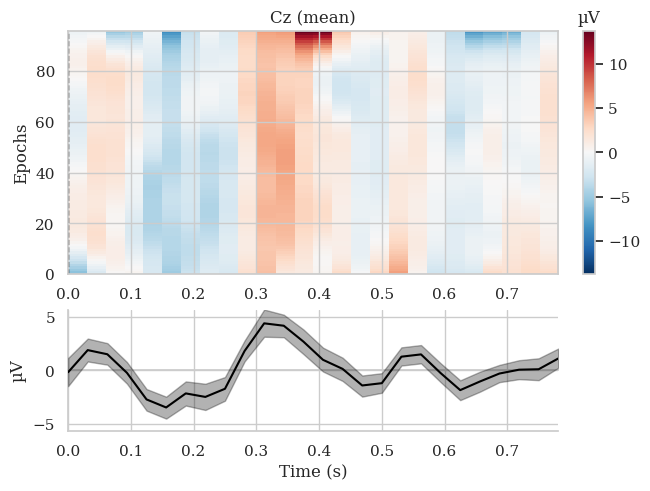

No projector specified for this dataset. Please consider the method self.add_proj.


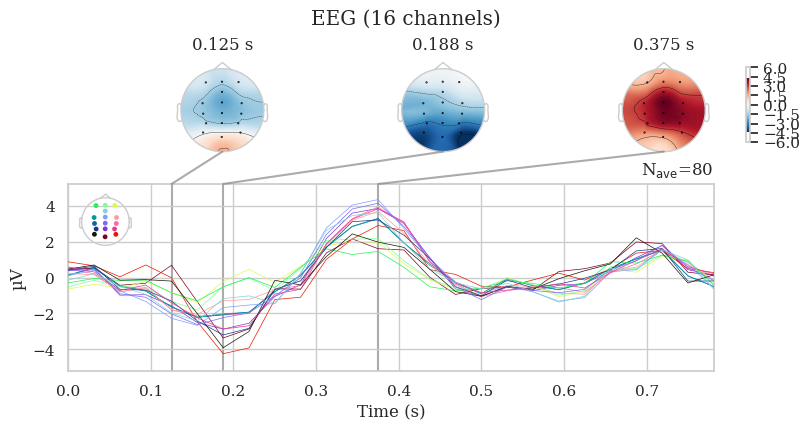

In [8]:
from mne import combine_evoked
import numpy as np

image_args=dict(picks=['Cz'], combine='mean', sigma=8)
epochs['Target'].plot_image(**image_args)


target = epochs['Target'].average()
non_target = epochs['NonTarget'].average()
contrast = combine_evoked([target,non_target], weights=[1,-1])
vmax = np.max(np.abs(contrast.data))*1.2*1e6
joint_args=dict(ts_args=dict(ylim=dict(eeg=[-vmax, vmax])))
_ = contrast.plot_joint(**joint_args)

No projector specified for this dataset. Please consider the method self.add_proj.


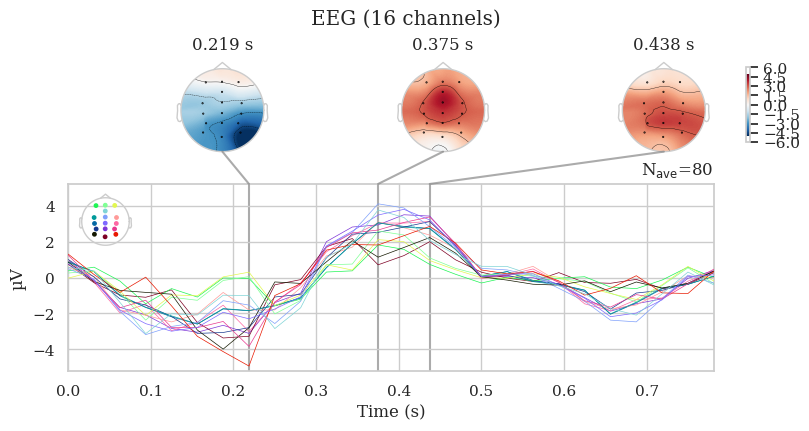

No projector specified for this dataset. Please consider the method self.add_proj.


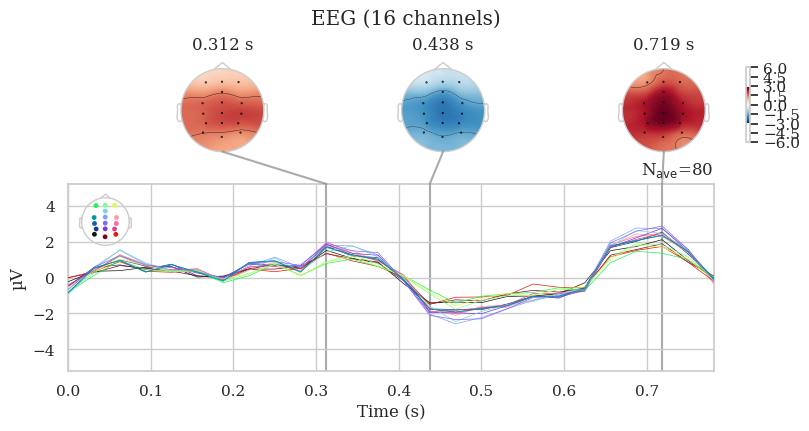

No projector specified for this dataset. Please consider the method self.add_proj.


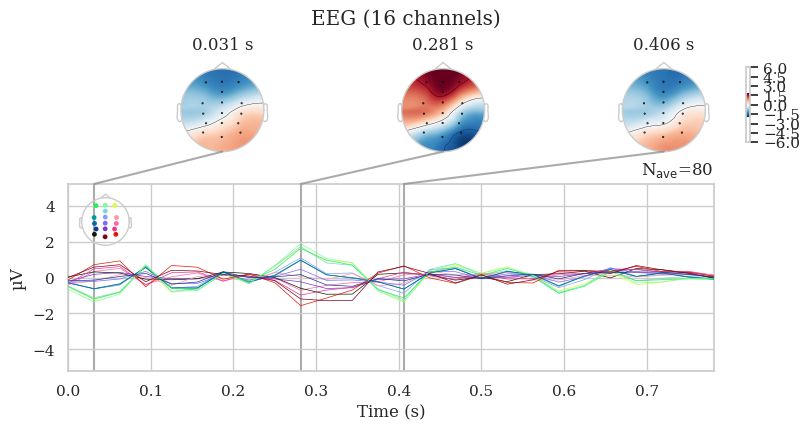

No projector specified for this dataset. Please consider the method self.add_proj.


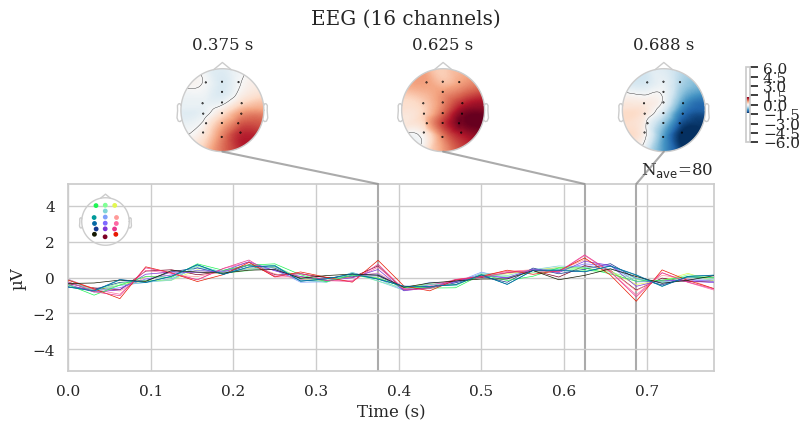

In [9]:
from mne import combine_evoked
from hoda.hoda import mse
from mne.viz import plot_compare_evokeds
import numpy as np

epochs_defl = epochs.copy()
epochs_rec = epochs.copy()
epochs_rec._data = np.zeros_like(epochs_rec.get_data())
evokeds = dict()
for b in range(len(bttda.blocks_)):
    epochs_block_rec = epochs.copy()
    epochs_block_rec._data = tl.to_numpy(bttda.blocks_[b].inv_transform(bttda.blocks_[b].transform(epochs_defl.get_data())))
    epochs_defl._data -= epochs_block_rec._data
    epochs_rec._data += epochs_block_rec._data
    
    target_block_rec = epochs_block_rec['Target'].average()
    non_target_block_rec = epochs_block_rec['NonTarget'].average()
    contrast_block_rec = combine_evoked([target_block_rec,non_target_block_rec], weights=[1,-1])
    evokeds[f'block {b}'] =contrast_block_rec
    contrast_block_rec.plot_joint(**joint_args)
    


Not setting metadata
96 matching events found
No baseline correction applied
0 projection items activated
combining channels using "mean"


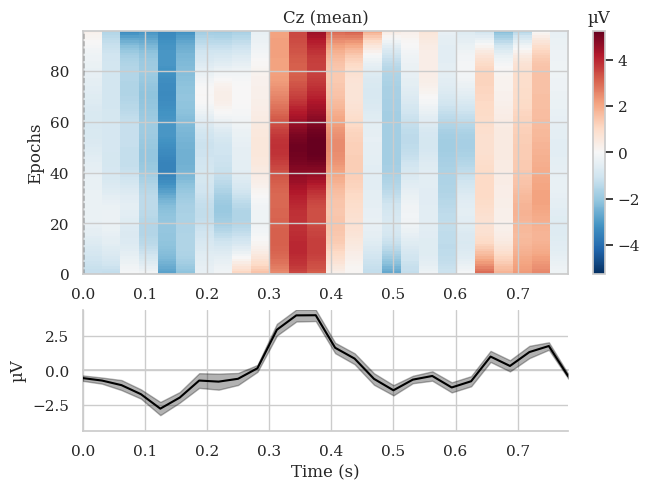

No projector specified for this dataset. Please consider the method self.add_proj.


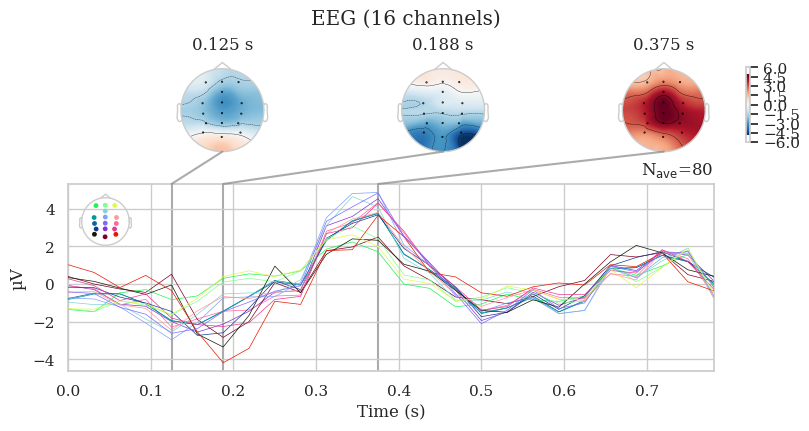

In [10]:
epochs_rec['Target'].plot_image(**image_args)
target_rec = epochs_rec['Target'].average()
non_target_rec = epochs_rec['NonTarget'].average()
contrast_rec = combine_evoked([target_rec,non_target_rec], weights=[1,-1])
_ = contrast_rec.plot_joint()

No projector specified for this dataset. Please consider the method self.add_proj.


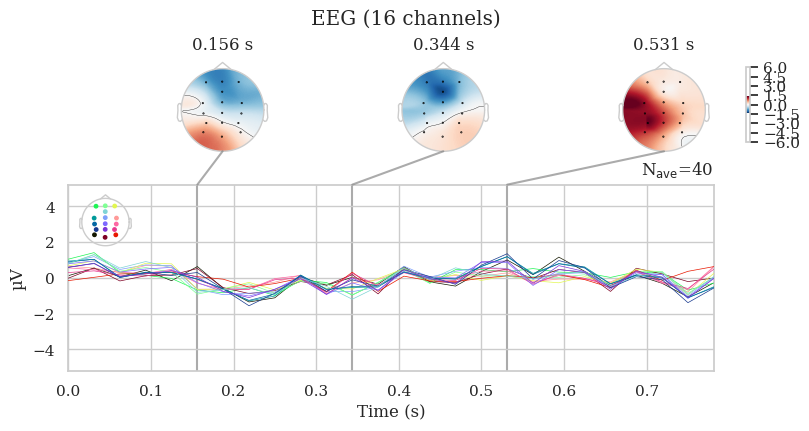

In [11]:
contrast_contrast_rec =  combine_evoked([contrast,contrast_rec], weights=[1,-1])
_ = contrast_contrast_rec.plot_joint(**joint_args)

In [12]:
Xt = bttda.transform(X)

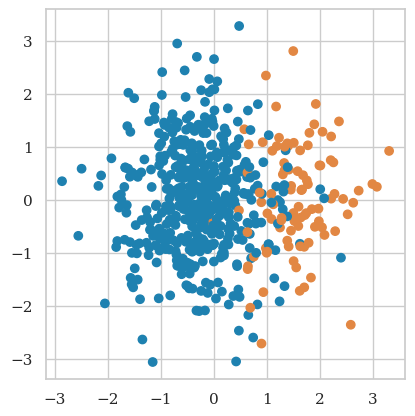

In [13]:
from sklearn.manifold import TSNE
import math
from sklearn.decomposition import PCA
import re, seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap

if Xt.shape[-1] > 1:
    n_components = 2
    decomp  = PCA(n_components=n_components, whiten=True)
    Xt_viz = decomp.fit_transform(tl.to_numpy(Xt))
    
    cmap = {'Target': '#e28743', 'NonTarget': '#1e81b0'}
    c = np.vectorize(cmap.get)(y)    
    fig, ax = plt.subplots(1,1)
    ax.scatter(Xt_viz[:,0], Xt_viz[:,1], c=c)
    ax.set_aspect('equal')


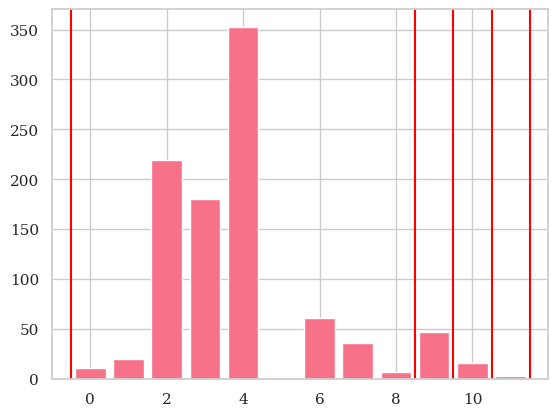

In [14]:
import scipy.stats
import seaborn as sns
import math

samples = []
for c in bttda.blocks_[0].classes_:
    samples.append(tl.to_numpy(Xt)[y==c])
F,p = scipy.stats.f_oneway(*samples, axis=0)
F = F.flatten()
p = p.flatten()
p = np.nan_to_num(p, nan=1)
fig, ax = plt.subplots(1,1)
plt.bar(np.arange(len(F)),F)
n_params=0
plt.axvline(n_params-.5, color='red')
for b in bttda.blocks_:
    n_params+=math.prod(b.ml_rank_)
    plt.axvline(n_params-.5, color='red')
